<a href="https://colab.research.google.com/github/Cristhianxn/swot/blob/master/Revisar_Comida.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Estimando fuerzas ofensivas/defensivas... (una sola vez)

  Costa de Marfil  vs  Ecuador
  (cancha neutral)
  Fuerza ofensiva (log):   Costa de Marfil +0.42  |  Ecuador +0.54
  Fuerza defensiva (log):  Costa de Marfil +0.66  |  Ecuador +1.09
  Goles esperados:         Costa de Marfil 0.70  |  Ecuador 1.21
------------------------------------------------------------
  Gana Costa de Marfil     20.0 %
  Empate                   33.0 %
  Gana Ecuador             47.0 %
------------------------------------------------------------
  Over 2.5 goles:           29.9 %
  Ambos marcan (BTTS):      36.7 %
  Marcador esperado:       0.70 - 1.21
------------------------------------------------------------
  Marcadores mas probables:
     Costa de Marfil 0 - 1 Ecuador    16.5 %
     Costa de Marfil 0 - 0 Ecuador    16.2 %
     Costa de Marfil 1 - 1 Ecuador    13.9 %
     Costa de Marfil 0 - 2 Ecuador    10.9 %
     Costa de Marfil 1 - 0 Ecuador     9.0 %



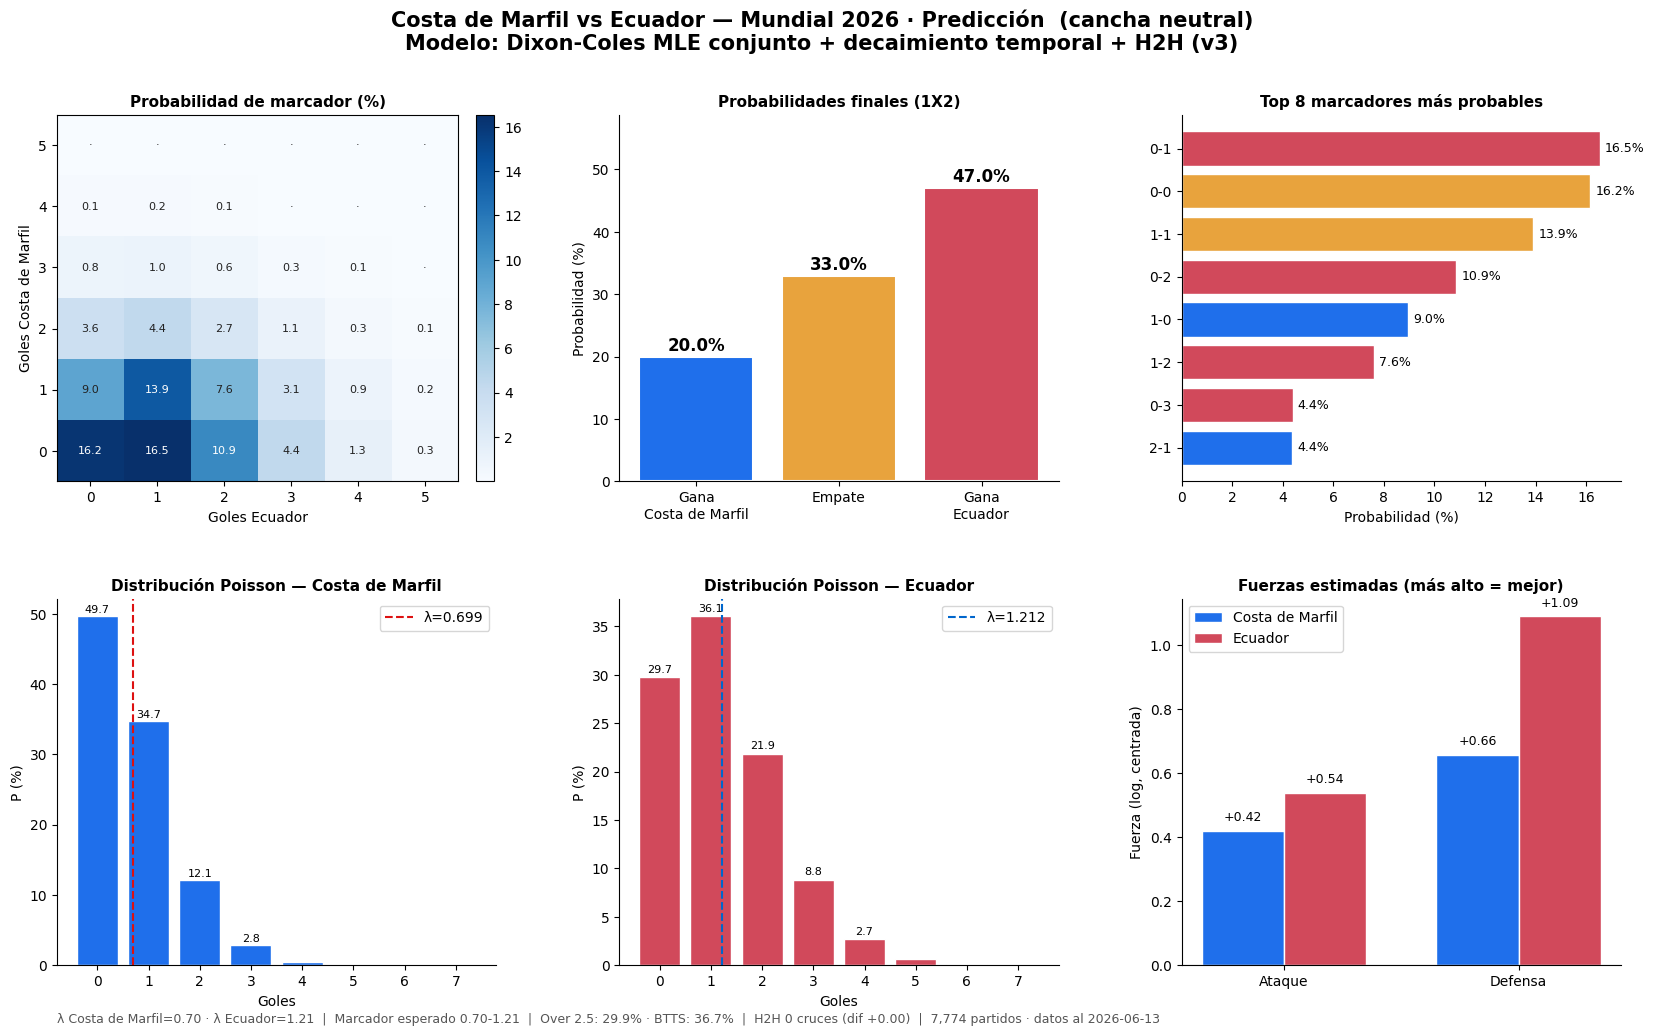

In [10]:
# ============================================================
#   >>> CAMBIA AQUI LOS EQUIPOS Y DALE PLAY  <<<
# ============================================================
EQUIPO_1 = "Ivory coast"
EQUIPO_2 = "Ecuador"
LOCAL    = None            # "a"=local EQUIPO_1, "b"=local EQUIPO_2, None=neutral
GUARDAR_PNG = None        # ruta .png para guardar, o None para solo mostrar
# ============================================================

try:
    import numpy, pandas, scipy, matplotlib
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "numpy", "pandas", "scipy", "matplotlib"])

# --- Render inline en notebooks (Colab/Jupyter): NO descarga archivos ---
try:
    from IPython import get_ipython
    _ip = get_ipython()
    if _ip is not None:
        _ip.run_line_magic("matplotlib", "inline")
except Exception:
    pass

"""
================================================================================
  PREDICTOR ESTADISTICO DE FUTBOL DE SELECCIONES  (v3 — con graficas)
================================================================================
  Motor: el mismo modelo Dixon-Coles de la v2 (estimacion CONJUNTA de
  ataque/defensa por maxima verosimilitud Poisson ponderada en el tiempo).
  No se toca la mecanica estadistica —que ya estaba bien— solo se anade un
  panel de 6 graficas al estilo del notebook ELO:

     1) Heatmap de probabilidad de cada marcador (matriz Dixon-Coles exacta)
     2) Probabilidades finales 1X2 (gana / empate / gana)
     3) Top 8 marcadores mas probables
     4) Distribucion Poisson de goles del equipo A (con su lambda)
     5) Distribucion Poisson de goles del equipo B (con su lambda)
     6) Fuerzas ofensiva/defensiva estimadas, comparadas

  Por que este motor y no el ELO de la captura:
  El v4-ELO usa el rating ELO como prior fijo; es razonable cuando hay pocos
  partidos en comun, pero introduce un parametro externo no estimado. El v2
  descuenta la calidad del rival de forma endogena (la fuerza sale de los
  propios goles), sin doble conteo. Aqui se conserva ese motor y se le da el
  mismo tablero visual.

  USO:   python3 predictor_futbol_v3_graficas.py
================================================================================
"""

import math, unicodedata
import numpy as np, pandas as pd

ALIASES = {
    "brasil":"Brazil","estados unidos":"United States","eeuu":"United States",
    "usa":"United States","alemania":"Germany","espana":"Spain","francia":"France",
    "inglaterra":"England","paises bajos":"Netherlands","holanda":"Netherlands",
    "belgica":"Belgium","croacia":"Croatia","suiza":"Switzerland","suecia":"Sweden",
    "noruega":"Norway","turquia":"Turkey","japon":"Japan","corea del sur":"South Korea",
    "corea":"South Korea","arabia saudita":"Saudi Arabia","iran":"Iran","catar":"Qatar",
    "qatar":"Qatar","marruecos":"Morocco","argelia":"Algeria","egipto":"Egypt",
    "ghana":"Ghana","tunez":"Tunisia","senegal":"Senegal","sudafrica":"South Africa",
    "costa de marfil":"Ivory Coast","mexico":"Mexico","canada":"Canada","panama":"Panama",
    "colombia":"Colombia","ecuador":"Ecuador","argentina":"Argentina","uruguay":"Uruguay",
    "paraguay":"Paraguay","peru":"Peru","chile":"Chile","venezuela":"Venezuela",
    "bolivia":"Bolivia","portugal":"Portugal","italia":"Italy","austria":"Austria",
    "australia":"Australia","nueva zelanda":"New Zealand",
}
# nombre bonito para mostrar en espanol
DISPLAY = {"Morocco":"Marruecos","Ivory Coast":"Costa de Marfil","Brazil":"Brasil",
           "Germany":"Alemania","Spain":"Espana","France":"Francia","England":"Inglaterra",
           "Netherlands":"Paises Bajos","Belgium":"Belgica","Croatia":"Croacia",
           "Switzerland":"Suiza","Japan":"Japon","South Korea":"Corea del Sur",
           "Saudi Arabia":"Arabia Saudita","Egypt":"Egipto","Tunisia":"Tunez",
           "South Africa":"Sudafrica","Mexico":"Mexico","Peru":"Peru"}

def _norm(s):
    s=unicodedata.normalize("NFKD",s).encode("ascii","ignore").decode()
    return " ".join(s.lower().split())
def display(t): return DISPLAY.get(t,t)

# --------------------------- PARAMETROS --------------------------- #
VENTANA_ANIOS=8; SEMIVIDA_ANIOS=3.0; PESO_AMISTOSO=0.40; RHO_DIXON_COLES=-0.11
MAX_GOLES=10; PESO_H2H=0.12; N_ITERACIONES=60; PRIOR_LOCALIA=0.22
URL_DATOS="https://raw.githubusercontent.com/martj42/international_results/master/results.csv"
RUTA_LOCAL="/tmp/results.csv"
C1="#1f6feb"; C2="#d1495b"; CN="#e8a33d"

# --------------------------- DATOS --------------------------- #
def cargar_datos():
    try: df=pd.read_csv(RUTA_LOCAL)
    except FileNotFoundError:
        print("Descargando historial de partidos..."); df=pd.read_csv(URL_DATOS)
        df.to_csv(RUTA_LOCAL,index=False)
    df=df.dropna(subset=["home_score","away_score"]).copy()
    df["home_score"]=df.home_score.astype(int); df["away_score"]=df.away_score.astype(int)
    df["date"]=pd.to_datetime(df.date); return df.sort_values("date").reset_index(drop=True)

# --------------------- AJUSTE DE FUERZAS --------------------- #
def ajustar_fuerzas(df,hoy):
    ventana=pd.Timedelta(days=int(365.25*VENTANA_ANIOS)); rec=df[df.date>=hoy-ventana]
    if len(rec)==0: rec=df
    mu=math.log(max(rec[["home_score","away_score"]].values.mean(),0.30))
    sv=365.25*SEMIVIDA_ANIOS; rows=[]
    for r in rec.itertuples(index=False):
        w=0.5**((hoy-r.date).days/sv)
        if r.tournament=="Friendly": w*=PESO_AMISTOSO
        rows.append((r.home_team,r.away_team,r.home_score,r.away_score,w,0 if r.neutral else 1))
    teams=pd.unique(rec[["home_team","away_team"]].values.ravel())
    atk={t:0.0 for t in teams}; defn={t:0.0 for t in teams}; localia=PRIOR_LOCALIA
    expo={t:0.0 for t in teams}
    for h,a,_,_,w,_ in rows: expo[h]+=w; expo[a]+=w
    W=sum(expo.values())
    for _ in range(N_ITERACIONES):
        na={t:0.0 for t in teams}; da={t:1e-9 for t in teams}
        nd={t:0.0 for t in teams}; dd={t:1e-9 for t in teams}; ln=ld=0.0
        for h,a,hs,as_,w,isl in rows:
            na[h]+=w*hs; da[h]+=w*math.exp(mu-defn[a]+localia*isl)
            na[a]+=w*as_; da[a]+=w*math.exp(mu-defn[h])
            nd[a]+=w*hs; dd[a]+=w*math.exp(mu+atk[h]+localia*isl)
            nd[h]+=w*as_; dd[h]+=w*math.exp(mu+atk[a])
            if isl: ln+=w*hs; ld+=w*math.exp(mu+atk[h]-defn[a])
        for t in teams:
            atk[t]=math.log(max(na[t]/da[t],1e-3)); defn[t]=-math.log(max(nd[t]/dd[t],1e-3))
        ma=sum(atk[t]*expo[t] for t in teams)/W; md=sum(defn[t]*expo[t] for t in teams)/W
        for t in teams: atk[t]-=ma; defn[t]-=md
        le=math.log(max(ln/ld,1e-3)) if ld>1e-6 else PRIOR_LOCALIA
        localia=0.5*le+0.5*PRIOR_LOCALIA
    return atk,defn,mu,localia,len(rec)

def head_to_head(df,a,b,hoy):
    m=(((df.home_team==a)&(df.away_team==b))|((df.home_team==b)&(df.away_team==a)))
    h=df[m].sort_values("date").tail(10)
    if len(h)==0: return 0.0,0
    dif=p=0.0
    for r in h.itertuples(index=False):
        w=0.5**((hoy-r.date).days/(365.25*6))
        dif+=((r.home_score-r.away_score) if r.home_team==a else (r.away_score-r.home_score))*w; p+=w
    return (dif/p if p else 0.0),len(h)

def lambdas_partido(atk,defn,mu,localia,ea,eb,hh,local):
    la=localia if local=="a" else 0.0; lb=localia if local=="b" else 0.0
    lam_a=math.exp(mu+atk[ea]-defn[eb]+la); lam_b=math.exp(mu+atk[eb]-defn[ea]+lb)
    lam_a*=math.exp(PESO_H2H*hh*0.15); lam_b*=math.exp(-PESO_H2H*hh*0.15)
    return float(np.clip(lam_a,0.15,5.0)),float(np.clip(lam_b,0.15,5.0))

def _tau(x,y,l,m,r):
    if x==0 and y==0: return 1-l*m*r
    if x==0 and y==1: return 1+l*r
    if x==1 and y==0: return 1+m*r
    if x==1 and y==1: return 1-r
    return 1.0
def matriz_probabilidades(l,m,rho=RHO_DIXON_COLES,mg=MAX_GOLES):
    from scipy.stats import poisson
    px=poisson.pmf(np.arange(mg+1),l); py=poisson.pmf(np.arange(mg+1),m)
    M=np.outer(px,py)
    for x in range(2):
        for y in range(2): M[x,y]*=_tau(x,y,l,m,rho)
    return M/M.sum()
def resumen_exacto(M):
    gx=np.arange(M.shape[0])[:,None]; gy=np.arange(M.shape[1])[None,:]
    return {"win_a":float(M[gx>gy].sum()),"empate":float(M[gx==gy].sum()),
            "win_b":float(M[gx<gy].sum()),"over25":float(M[(gx+gy)>2].sum()),
            "btts":float(M[(gx>0)&(gy>0)].sum()),
            "goles_a":float((M.sum(1)*np.arange(M.shape[0])).sum()),
            "goles_b":float((M.sum(0)*np.arange(M.shape[1])).sum())}

def resolver_equipo(atk,nombre):
    nl=_norm(nombre)
    if nl in ALIASES and ALIASES[nl] in atk: return ALIASES[nl]
    for e in atk:
        if _norm(e)==nl: return e
    cand=[e for e in atk if nl in _norm(e) or _norm(e) in nl]
    if len(cand)==1: return cand[0]
    if len(cand)>1:
        cand.sort(key=lambda e:(abs(len(_norm(e))-len(nl)),_norm(e)))
        print(f"  '{nombre}' ambiguo. Uso '{cand[0]}'."); return cand[0]
    return None

# --------------------------- GRAFICAS --------------------------- #
def graficar(ea,eb,atk,defn,la,lb,M,res,hh,nh,n,hoy,local,ruta):
    import matplotlib.pyplot as plt
    from matplotlib import gridspec
    from scipy.stats import poisson
    n1,n2=display(ea),display(eb)
    top=sorted(((M[x,y],x,y) for x in range(M.shape[0]) for y in range(M.shape[1])),reverse=True)[:8]

    fig=plt.figure(figsize=(17,10.5),facecolor="white")
    locs={"a":f"(local: {n1})","b":f"(local: {n2})",None:"(cancha neutral)"}[local]
    fig.suptitle(f"{n1} vs {n2} — Mundial 2026 · Predicción  {locs}\n"
                 f"Modelo: Dixon-Coles MLE conjunto + decaimiento temporal + H2H (v3)",
                 fontsize=15,fontweight="bold",y=0.98)
    gs=gridspec.GridSpec(2,3,hspace=0.32,wspace=0.28,top=0.88,bottom=0.07,left=0.05,right=0.97)

    ax=fig.add_subplot(gs[0,0]); mg=6; sub=M[:mg,:mg]*100
    im=ax.imshow(sub,cmap="Blues",origin="lower",aspect="auto")
    for x in range(mg):
        for y in range(mg):
            v=sub[x,y]
            ax.text(y,x,f"{v:.1f}" if v>=0.05 else "·",ha="center",va="center",
                    fontsize=8,color="white" if v>sub.max()*0.55 else "#222")
    ax.set_xlabel(f"Goles {n2}"); ax.set_ylabel(f"Goles {n1}")
    ax.set_title("Probabilidad de marcador (%)",fontweight="bold",fontsize=11)
    ax.set_xticks(range(mg)); ax.set_yticks(range(mg)); plt.colorbar(im,ax=ax,fraction=0.046,pad=0.04)

    ax=fig.add_subplot(gs[0,1]); vals=[res["win_a"]*100,res["empate"]*100,res["win_b"]*100]
    bars=ax.bar([f"Gana\n{n1}","Empate",f"Gana\n{n2}"],vals,color=[C1,CN,C2],edgecolor="white",linewidth=1.5)
    for b,v in zip(bars,vals): ax.text(b.get_x()+b.get_width()/2,v+1,f"{v:.1f}%",ha="center",fontweight="bold",fontsize=12)
    ax.set_ylim(0,max(vals)*1.25); ax.set_ylabel("Probabilidad (%)")
    ax.set_title("Probabilidades finales (1X2)",fontweight="bold",fontsize=11); ax.spines[["top","right"]].set_visible(False)

    ax=fig.add_subplot(gs[0,2])
    tl=[f"{x}-{y}" for _,x,y in top][::-1]; tv=[p*100 for p,_,_ in top][::-1]
    tc=[C1 if x>y else (CN if x==y else C2) for _,x,y in top][::-1]
    ax.barh(tl,tv,color=tc,edgecolor="white")
    for i,v in enumerate(tv): ax.text(v+0.2,i,f"{v:.1f}%",va="center",fontsize=9)
    ax.set_xlabel("Probabilidad (%)"); ax.set_title("Top 8 marcadores más probables",fontweight="bold",fontsize=11)
    ax.spines[["top","right"]].set_visible(False)

    k=np.arange(8)
    ax=fig.add_subplot(gs[1,0]); pk=poisson.pmf(k,la)*100; ax.bar(k,pk,color=C1,edgecolor="white")
    for i,v in enumerate(pk):
        if v>2: ax.text(i,v+0.5,f"{v:.1f}",ha="center",fontsize=8)
    ax.axvline(la,ls="--",color="#d11",lw=1.5,label=f"λ={la:.3f}"); ax.legend()
    ax.set_xlabel("Goles"); ax.set_ylabel("P (%)"); ax.set_title(f"Distribución Poisson — {n1}",fontweight="bold",fontsize=11)
    ax.spines[["top","right"]].set_visible(False)

    ax=fig.add_subplot(gs[1,1]); pk2=poisson.pmf(k,lb)*100; ax.bar(k,pk2,color=C2,edgecolor="white")
    for i,v in enumerate(pk2):
        if v>2: ax.text(i,v+0.5,f"{v:.1f}",ha="center",fontsize=8)
    ax.axvline(lb,ls="--",color="#06c",lw=1.5,label=f"λ={lb:.3f}"); ax.legend()
    ax.set_xlabel("Goles"); ax.set_ylabel("P (%)"); ax.set_title(f"Distribución Poisson — {n2}",fontweight="bold",fontsize=11)
    ax.spines[["top","right"]].set_visible(False)

    ax=fig.add_subplot(gs[1,2]); x=np.arange(2); w=0.35
    v1=[atk[ea],defn[ea]]; v2=[atk[eb],defn[eb]]
    ax.bar(x-w/2,v1,w,label=n1,color=C1,edgecolor="white"); ax.bar(x+w/2,v2,w,label=n2,color=C2,edgecolor="white")
    ax.axhline(0,color="#999",lw=0.8)
    for i,v in enumerate(v1): ax.text(i-w/2,v+(0.03 if v>=0 else -0.06),f"{v:+.2f}",ha="center",fontsize=9)
    for i,v in enumerate(v2): ax.text(i+w/2,v+(0.03 if v>=0 else -0.06),f"{v:+.2f}",ha="center",fontsize=9)
    ax.set_xticks(x); ax.set_xticklabels(["Ataque","Defensa"]); ax.legend(); ax.set_ylabel("Fuerza (log, centrada)")
    ax.set_title("Fuerzas estimadas (más alto = mejor)",fontweight="bold",fontsize=11); ax.spines[["top","right"]].set_visible(False)

    fig.text(0.05,0.015,
      f"λ {n1}={la:.2f} · λ {n2}={lb:.2f}  |  Marcador esperado {res['goles_a']:.2f}-{res['goles_b']:.2f}  |  "
      f"Over 2.5: {res['over25']*100:.1f}% · BTTS: {res['btts']*100:.1f}%  |  "
      f"H2H {nh} cruces (dif {hh:+.2f})  |  {n:,} partidos · datos al {hoy.date()}",fontsize=9,color="#555")
    if ruta:
        plt.savefig(ruta,dpi=130,bbox_inches="tight",facecolor="white"); print(f"  Grafica guardada en: {ruta}")
    try: plt.show()
    except Exception: pass

# --------------------------- PRINCIPAL --------------------------- #
_CACHE={}
def _init():
    if "atk" not in _CACHE:
        df=cargar_datos(); hoy=df.date.max()
        print("Estimando fuerzas ofensivas/defensivas... (una sola vez)")
        atk,defn,mu,loc,n=ajustar_fuerzas(df,hoy)
        _CACHE.update(df=df,hoy=hoy,atk=atk,defn=defn,mu=mu,localia=loc,n=n)

def predecir(equipo_a,equipo_b,local=None,verbose=True,guardar=GUARDAR_PNG):
    _init(); df,hoy=_CACHE["df"],_CACHE["hoy"]
    atk,defn,mu,loc=_CACHE["atk"],_CACHE["defn"],_CACHE["mu"],_CACHE["localia"]
    ea=resolver_equipo(atk,equipo_a); eb=resolver_equipo(atk,equipo_b)
    if ea is None: print(f"No encontre: '{equipo_a}'"); return
    if eb is None: print(f"No encontre: '{equipo_b}'"); return
    hh,nh=head_to_head(df,ea,eb,hoy); la,lb=lambdas_partido(atk,defn,mu,loc,ea,eb,hh,local)
    M=matriz_probabilidades(la,lb); res=resumen_exacto(M)
    top=sorted(((M[x,y],x,y) for x in range(M.shape[0]) for y in range(M.shape[1])),reverse=True)
    n1,n2=display(ea),display(eb)
    if verbose:
        print("\n"+"="*60); print(f"  {n1}  vs  {n2}")
        print(f"  { '(local: '+n1+')' if local=='a' else '(local: '+n2+')' if local=='b' else '(cancha neutral)'}")
        print("="*60)
        print(f"  Fuerza ofensiva (log):   {n1} {atk[ea]:+.2f}  |  {n2} {atk[eb]:+.2f}")
        print(f"  Fuerza defensiva (log):  {n1} {defn[ea]:+.2f}  |  {n2} {defn[eb]:+.2f}")
        if nh: print(f"  Head-to-head:            {nh} cruces, dif. neta {hh:+.2f} pro {n1}")
        print(f"  Goles esperados:         {n1} {la:.2f}  |  {n2} {lb:.2f}")
        print("-"*60)
        print(f"  Gana {n1:<18} {res['win_a']*100:5.1f} %")
        print(f"  Empate{'':<17} {res['empate']*100:5.1f} %")
        print(f"  Gana {n2:<18} {res['win_b']*100:5.1f} %")
        print("-"*60)
        print(f"  Over 2.5 goles:          {res['over25']*100:5.1f} %")
        print(f"  Ambos marcan (BTTS):     {res['btts']*100:5.1f} %")
        print(f"  Marcador esperado:       {res['goles_a']:.2f} - {res['goles_b']:.2f}")
        print("-"*60); print("  Marcadores mas probables:")
        for p,x,y in top[:5]: print(f"     {n1} {x} - {y} {n2}   {p*100:5.1f} %")
        print("="*60+"\n")
    graficar(ea,eb,atk,defn,la,lb,M,res,hh,nh,_CACHE["n"],hoy,local,guardar)
    return {"equipo_a":ea,"equipo_b":eb,"lam_a":la,"lam_b":lb,**res,
            "top_marcadores":[(x,y,float(p)) for p,x,y in top[:5]]}

if __name__=="__main__":
    predecir(EQUIPO_1,EQUIPO_2,local=LOCAL)
